<a href="https://colab.research.google.com/github/shirin6767saleh/code-/blob/Fnew/comparisonF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

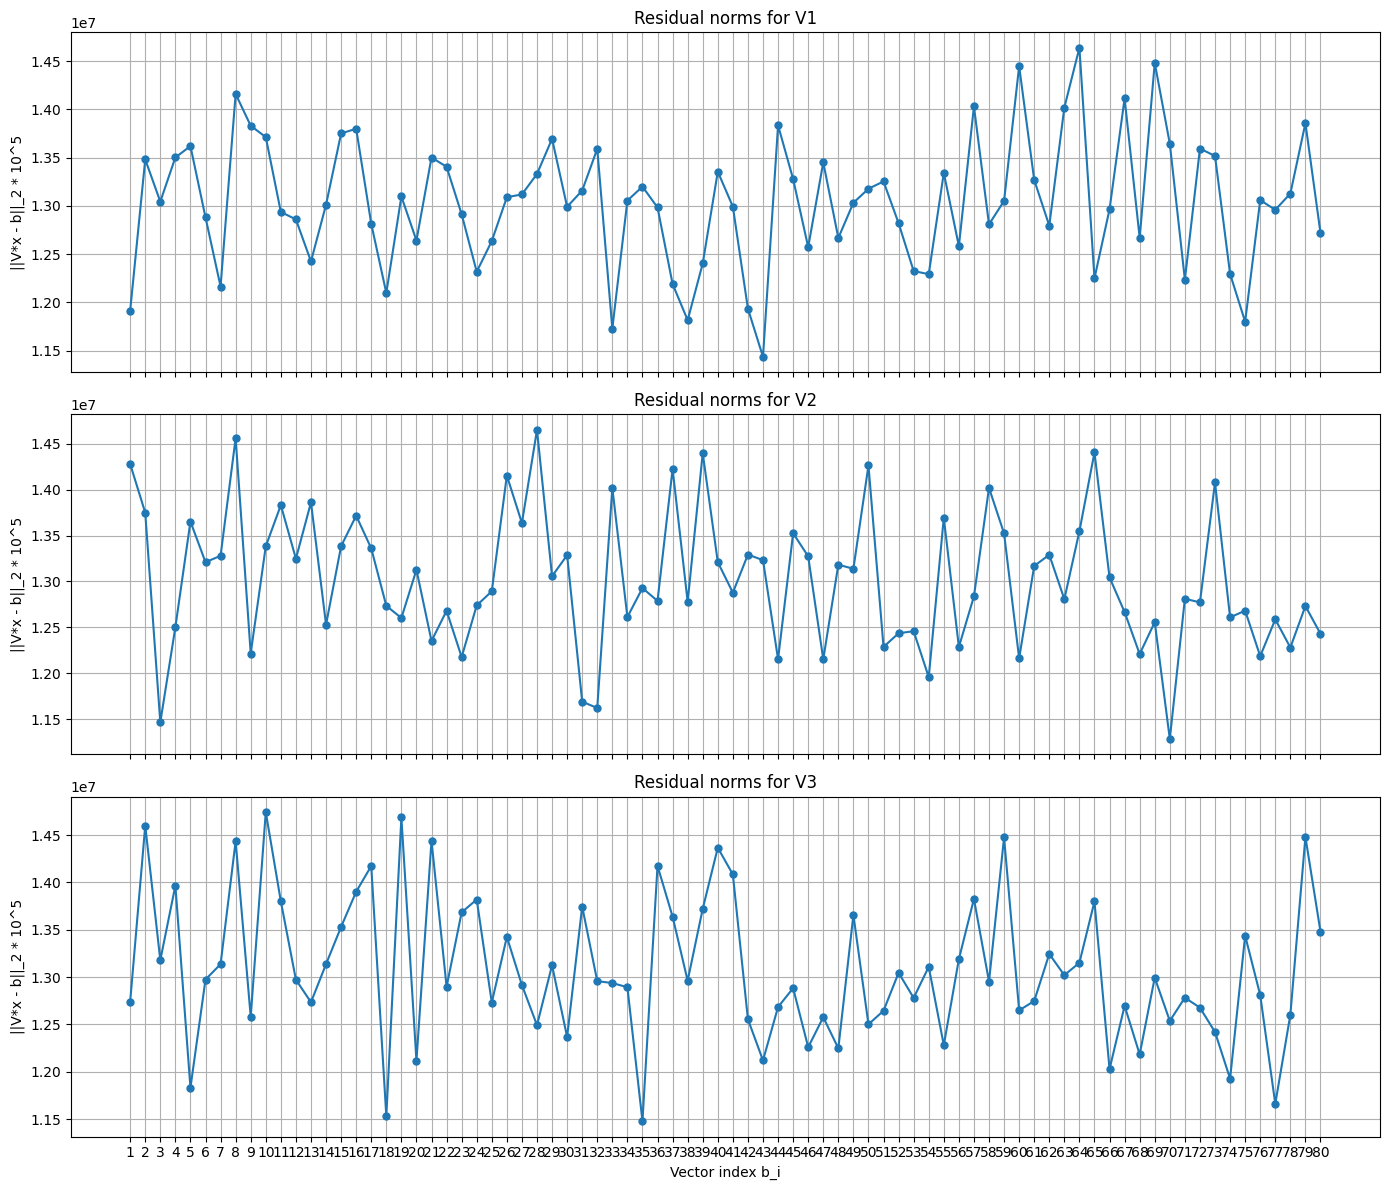

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# PARAMETERS
# ----------------------------
m = 200
N = 4*m + 2
numVectors = 80

theta = 0
p = 0
t = 2*p

# ----------------------------
# 1) FIRST V (V1)
# ----------------------------
w1 = np.exp(-2j * np.pi / N)
G1 = np.zeros((N, N), dtype=complex)
for k in range(N):
    for l in range(N):
        G1[k, l] = (1/np.sqrt(N)) * w1**((k - theta/2) * (l - theta/2))

DCT = np.real(G1)
DST = np.imag(G1)

DCT2 = DCT @ DCT
DST2 = DST @ DST

P_1  = 0.25 * (DCT2 + DCT)
P_m1 = 0.25 * (DCT2 - DCT)
P_i  = 0.25 * (DST2 - DST)
P_mi = 0.25 * (DST2 + DST)

X1 = P_1[:, 0:m+1]
Y1 = P_m1[:, 0:m+1]
Z1 = P_i[:, 1:m+1]
T1 = P_mi[:, 1:m+1]

V1_matrix = np.hstack([X1, Y1, Z1, T1])

# ----------------------------
# 2) SECOND V (V2)
# ----------------------------
k_idx = np.arange(N).reshape(N, 1)
l_idx = np.arange(N).reshape(1, N)

DCT2b = (1/np.sqrt(N)) * np.cos(2*np.pi*k_idx*l_idx/N)
DST2b = (1/np.sqrt(N)) * np.sin(2*np.pi*k_idx*l_idx/N)

delta_0 = np.zeros((N, N))
delta_0[0, :] = 1
delta_l = np.eye(N)
delta_N_l = np.fliplr(np.eye(N))

P1b   = DCT2b + 0.5*(delta_0 + delta_l + delta_N_l)
P_m1b = DCT2b - 0.5*(delta_0 + delta_l + delta_N_l)
P_ib  = DST2b - 0.5*(delta_l - delta_N_l)
P_mib = DST2b + 0.5*(delta_l - delta_N_l)

X2 = P1b[:, 0:m+1]
Y2 = P_m1b[:, 0:m+1]
Z2 = P_ib[:, 1:m+1]
T2 = P_mib[:, 1:m+1]

V2_matrix = np.hstack([X2, Y2, Z2, T2])

# ----------------------------
# 3) THIRD V (V3, MATLAB style)
# ----------------------------
w3 = np.exp(-2j * np.pi / N)
Gt = np.zeros((N, N), dtype=complex)
for k in range(N):
    for l in range(N):
        Gt[k, l] = (1/np.sqrt(N)) * w3**((k - t/2) * (l - t/2))

C = np.real(Gt)
S = np.imag(Gt)

P = 0.5*np.eye(N)
P[0, 0] = 1
P[2*m+1, 2*m+1] = 1

for k in range(1, 2*m + 1):
    P[k, N-k] = 0.5
    P[k+2*m+1, N-k-2*m-1] = -0.5

Ph = P
Ph_inv = np.linalg.inv(Ph)

V_tmp = Ph @ C @ Ph_inv
W_tmp = Ph @ S @ Ph_inv

A = V_tmp[0:2*m+2, 0:2*m+2]
B = W_tmp[2*m+2:N, 2*m+2:N]

X_sub = (A + np.eye(2*m+2))[:, 0:m+1]
Y_sub = (A - np.eye(2*m+2))[:, 0:m+1]
Z_sub = (B + np.eye(2*m))[:, 0:m]
T_sub = (B - np.eye(2*m))[:, 0:m]

pad_rows_XY = N - X_sub.shape[0]
X3 = Ph_inv @ np.vstack([X_sub, np.zeros((pad_rows_XY, m+1))])
Y3 = Ph_inv @ np.vstack([Y_sub, np.zeros((pad_rows_XY, m+1))])

pad_rows_ZT = N - Z_sub.shape[0]
Z3 = Ph_inv @ np.vstack([np.zeros((pad_rows_ZT, m)), Z_sub])
T3 = Ph_inv @ np.vstack([np.zeros((pad_rows_ZT, m)), T_sub])

V3_matrix = np.hstack([X3, Y3, Z3, T3])

# ----------------------------
# Plot Euclidean norms of residuals
# ----------------------------
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

def plot_residual_norms(ax, V, label_prefix):
    norms = []
    for idx in range(numVectors):
        b = np.random.randn(N) * 10
        x = np.linalg.lstsq(V, b, rcond=None)[0]
        residual = V @ x - b
        norm_residual = np.linalg.norm(residual) * 1e5
        norms.append(norm_residual)
    ax.plot(range(1, numVectors+1), norms, '-o', markersize=5)
    ax.set_ylabel("||V*x - b||_2 * 10^5")
    ax.grid(True)
    ax.set_xticks(range(1, numVectors+1))
    ax.set_title(f"Residual norms for {label_prefix}")

plot_residual_norms(axes[0], V1_matrix, "V1")
plot_residual_norms(axes[1], V2_matrix, "V2")
plot_residual_norms(axes[2], V3_matrix, "V3")
axes[2].set_xlabel("Vector index b_i")

plt.tight_layout()
plt.show()


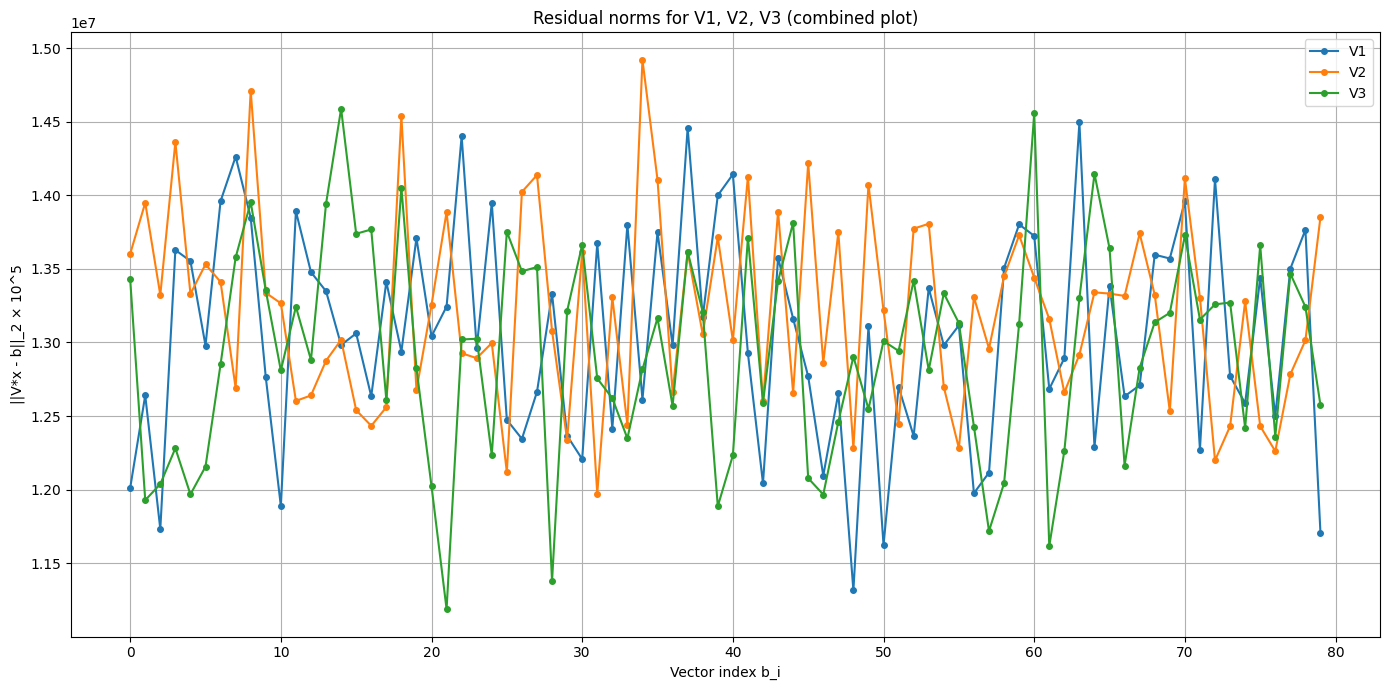

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# PARAMETERS
# ----------------------------
m = 200
N = 4*m + 2
numVectors = 80

theta = 0
p = 0
t = 2*p

# ----------------------------
# 1) FIRST V (V1)
# ----------------------------
w1 = np.exp(-2j * np.pi / N)
G1 = np.zeros((N, N), dtype=complex)
for k in range(N):
    for l in range(N):
        G1[k, l] = (1/np.sqrt(N)) * w1**((k - theta/2) * (l - theta/2))

DCT = np.real(G1)
DST = np.imag(G1)

DCT2 = DCT @ DCT
DST2 = DST @ DST

P_1  = 0.25 * (DCT2 + DCT)
P_m1 = 0.25 * (DCT2 - DCT)
P_i  = 0.25 * (DST2 - DST)
P_mi = 0.25 * (DST2 + DST)

X1 = P_1[:, 0:m+1]
Y1 = P_m1[:, 0:m+1]
Z1 = P_i[:, 1:m+1]
T1 = P_mi[:, 1:m+1]

V1_matrix = np.hstack([X1, Y1, Z1, T1])

# ----------------------------
# 2) SECOND V (V2)
# ----------------------------
k_idx = np.arange(N).reshape(N, 1)
l_idx = np.arange(N).reshape(1, N)

DCT2b = (1/np.sqrt(N)) * np.cos(2*np.pi*k_idx*l_idx/N)
DST2b = (1/np.sqrt(N)) * np.sin(2*np.pi*k_idx*l_idx/N)

delta_0 = np.zeros((N, N))
delta_0[0, :] = 1
delta_l = np.eye(N)
delta_N_l = np.fliplr(np.eye(N))

P1b   = DCT2b + 0.5*(delta_0 + delta_l + delta_N_l)
P_m1b = DCT2b - 0.5*(delta_0 + delta_l + delta_N_l)
P_ib  = DST2b - 0.5*(delta_l - delta_N_l)
P_mib = DST2b + 0.5*(delta_l - delta_N_l)

X2 = P1b[:, 0:m+1]
Y2 = P_m1b[:, 0:m+1]
Z2 = P_ib[:, 1:m+1]
T2 = P_mib[:, 1:m+1]

V2_matrix = np.hstack([X2, Y2, Z2, T2])

# ----------------------------
# 3) THIRD V (V3)
# ----------------------------
w3 = np.exp(-2j * np.pi / N)
Gt = np.zeros((N, N), dtype=complex)
for k in range(N):
    for l in range(N):
        Gt[k, l] = (1/np.sqrt(N)) * w3**((k - t/2) * (l - t/2))

C = np.real(Gt)
S = np.imag(Gt)

P = 0.5*np.eye(N)
P[0, 0] = 1
P[2*m+1, 2*m+1] = 1

for k in range(1, 2*m + 1):
    P[k, N-k] = 0.5
    P[k+2*m+1, N-k-2*m-1] = -0.5

Ph = P
Ph_inv = np.linalg.inv(Ph)

V_tmp = Ph @ C @ Ph_inv
W_tmp = Ph @ S @ Ph_inv

A = V_tmp[0:2*m+2, 0:2*m+2]
B = W_tmp[2*m+2:N, 2*m+2:N]

X_sub = (A + np.eye(2*m+2))[:, 0:m+1]
Y_sub = (A - np.eye(2*m+2))[:, 0:m+1]
Z_sub = (B + np.eye(2*m))[:, 0:m]
T_sub = (B - np.eye(2*m))[:, 0:m]

pad_rows_XY = N - X_sub.shape[0]
X3 = Ph_inv @ np.vstack([X_sub, np.zeros((pad_rows_XY, m+1))])
Y3 = Ph_inv @ np.vstack([Y_sub, np.zeros((pad_rows_XY, m+1))])

pad_rows_ZT = N - Z_sub.shape[0]
Z3 = Ph_inv @ np.vstack([np.zeros((pad_rows_ZT, m)), Z_sub])
T3 = Ph_inv @ np.vstack([np.zeros((pad_rows_ZT, m)), T_sub])

V3_matrix = np.hstack([X3, Y3, Z3, T3])

# ----------------------------
# Compute norms & single figure plot
# ----------------------------
def compute_norms(V):
    norms = []
    for idx in range(numVectors):
        b = np.random.randn(N) * 10
        x = np.linalg.lstsq(V, b, rcond=None)[0]
        norms.append(np.linalg.norm(V @ x - b) * 1e5)
    return norms

norms_V1 = compute_norms(V1_matrix)
norms_V2 = compute_norms(V2_matrix)
norms_V3 = compute_norms(V3_matrix)

plt.figure(figsize=(14, 7))
plt.plot(norms_V1, '-o', label="V1", markersize=4)
plt.plot(norms_V2, '-o', label="V2", markersize=4)
plt.plot(norms_V3, '-o', label="V3", markersize=4)

plt.xlabel("Vector index b_i")
plt.ylabel("||V*x - b||_2 × 10^5")
plt.grid(True)
plt.title("Residual norms for V1, V2, V3 (combined plot)")
plt.legend()
plt.tight_layout()
plt.show()
